In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

In [59]:
months = pd.date_range(start='2020-02-01', end='2020-05-01', freq='MS').strftime('%Y%m')

bids_list = []
asks_list = []

# Only load the columns that actually matter to save massive amounts of RAM
cols_to_keep = ['datetime', 'price', 'volume']

for m in months:
    try:
        # Pass the columns argument to only read what we need
        bid = pd.read_parquet(
            f"../data/processed/eurusd_dukascopy_bid_{m}.parquet", 
            columns=cols_to_keep
        )
        ask = pd.read_parquet(
            f"../data/processed/eurusd_dukascopy_ask_{m}.parquet", 
            columns=cols_to_keep
        )
        
        bids_list.append(bid)
        asks_list.append(ask)
        
    except FileNotFoundError:
        print(f"Skipping {m}: File(s) not found.")

print("Concatenating Bids...")
df_bid = pd.concat(bids_list, ignore_index=True)

print("Concatenating Asks...")
df_ask = pd.concat(asks_list, ignore_index=True)

print("Sorting Bids...")
df_bid = df_bid.sort_values('datetime')

print("Sorting Asks...")
df_ask = df_ask.sort_values('datetime')

print("Done!")

print(df_bid)
print(df_ask)

Concatenating Bids...
Concatenating Asks...
Sorting Bids...
Sorting Asks...
Done!
                                 datetime    price  volume
0        2020-02-02 22:00:14.503000+00:00  1.10939    0.75
1        2020-02-02 22:01:04.028000+00:00  1.10934    0.75
2        2020-02-02 22:01:04.096000+00:00  1.10922    0.75
3        2020-02-02 22:01:04.758000+00:00  1.10921    0.75
4        2020-02-02 22:02:18.551000+00:00  1.10922    0.75
...                                   ...      ...     ...
12006741 2020-05-31 23:59:58.192000+00:00  1.11158    3.82
12006742 2020-05-31 23:59:58.293000+00:00  1.11158    3.07
12006743 2020-05-31 23:59:58.881000+00:00  1.11157    3.37
12006744 2020-05-31 23:59:58.982000+00:00  1.11156    3.07
12006745 2020-05-31 23:59:59.084000+00:00  1.11156    3.07

[12006746 rows x 3 columns]
                                 datetime    price  volume
0        2020-02-02 22:00:14.503000+00:00  1.10957    0.75
1        2020-02-02 22:01:04.028000+00:00  1.10943    0.75
2   

In [60]:
# Rename columns before merging so we know what is what
df_bid_clean = df_bid.rename(columns={'price': 'bid', 'volume': 'bid_vol'})
df_ask_clean = df_ask.rename(columns={'price': 'ask', 'volume': 'ask_vol'})

print("Aligning ticks and merging...")
# merge_asof matches each bid with the most recent ask that happened at or just before it
df = pd.merge_asof(
    df_bid_clean,
    df_ask_clean,
    on='datetime',
    direction='backward'
)

# Calculate our key metrics
df['mid'] = (df['bid'] + df['ask']) / 2
df['spread'] = df['ask'] - df['bid']

# Move datetime to the index for time-series analysis
df = df.set_index('datetime')
df_bid = df_bid.set_index('datetime')
df_ask = df_ask.set_index('datetime')

print("Merge complete! df is ready.")

Aligning ticks and merging...
Merge complete! df is ready.


### Processing and pre-averaging to 1000 ticks

In [61]:
# Create 1000-tick bars from our merged df
tick_window = 1000
df['tick_group'] = np.arange(len(df)) // tick_window

df_bars = df.groupby('tick_group').agg({
    'mid': 'last',          # Close price of the tick bar
    'spread': 'mean',       # Average spread
    'bid_vol': 'sum',
    'ask_vol': 'sum'
})

df_bars['log_return'] = np.log(df_bars['mid'] / df_bars['mid'].shift(1))
df_bars = df_bars.dropna()

### Mid Price Series

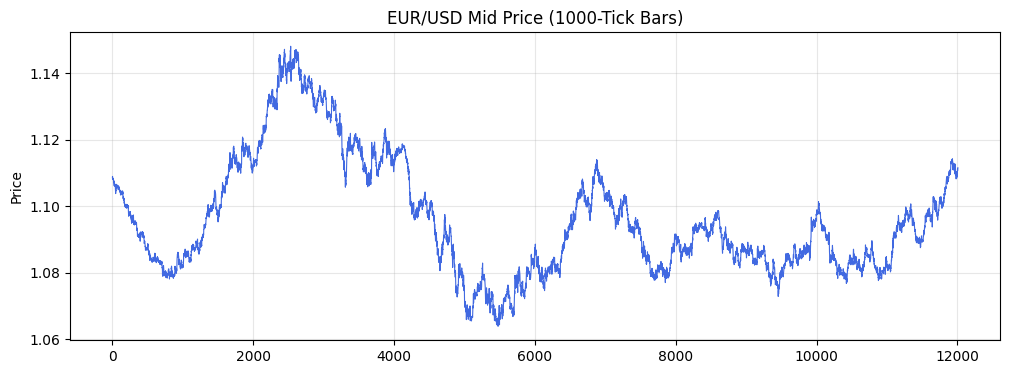

In [62]:
plt.figure(figsize=(12, 4))
plt.plot(df_bars.index, df_bars['mid'], color='royalblue', linewidth=0.8)
plt.title('EUR/USD Mid Price (1000-Tick Bars)')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.show()

### Log Returns

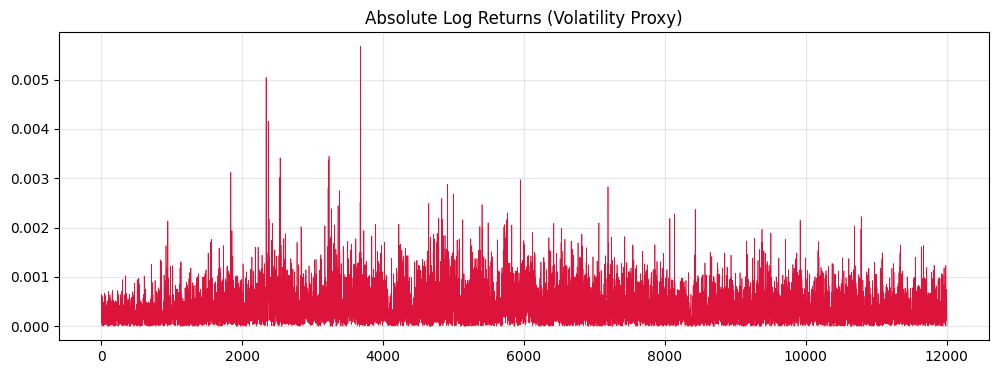

In [63]:
plt.figure(figsize=(12, 4))
plt.plot(df_bars.index, df_bars['log_return'].abs(), color='crimson', linewidth=0.5)
plt.title('Absolute Log Returns (Volatility Proxy)')
plt.grid(True, alpha=0.3)
plt.show()

### Absolute Returns (Volatility Proxy)

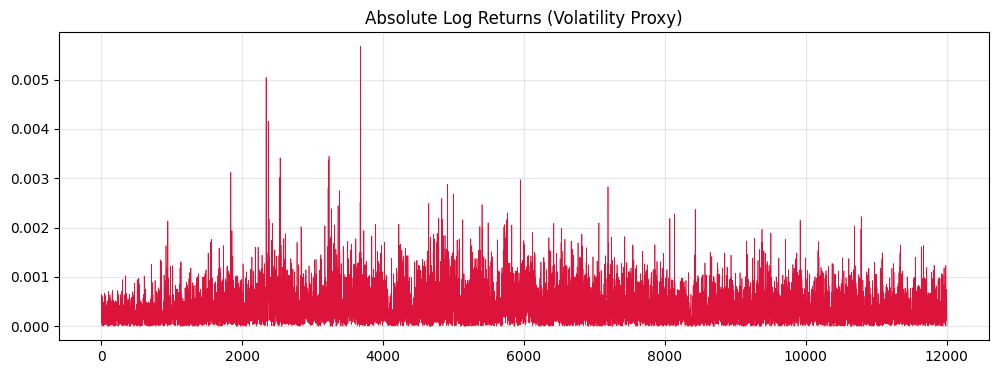

In [64]:
plt.figure(figsize=(12, 4))
plt.plot(df_bars.index, df_bars['log_return'].abs(), color='crimson', linewidth=0.5)
plt.title('Absolute Log Returns (Volatility Proxy)')
plt.grid(True, alpha=0.3)
plt.show()

### Rolling Volatility (Standard Deviation)

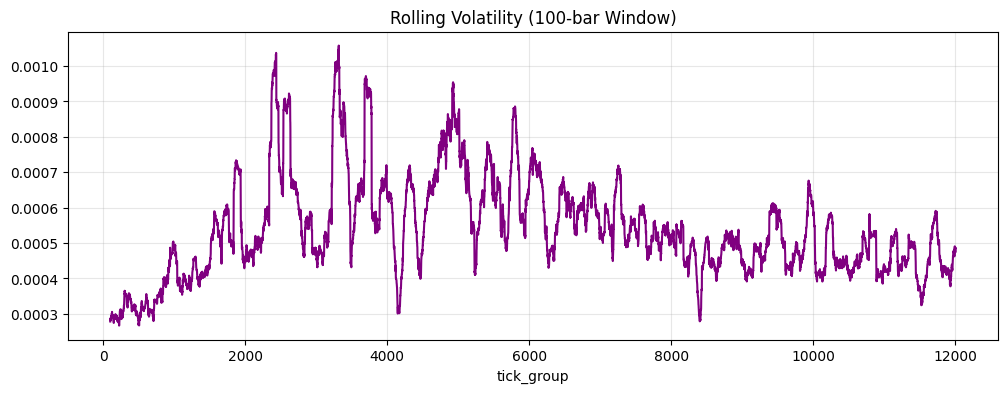

In [65]:
plt.figure(figsize=(12, 4))
df_bars['log_return'].rolling(window=100).std().plot(color='purple')
plt.title('Rolling Volatility (100-bar Window)')
plt.grid(True, alpha=0.3)
plt.show()

### Histogram of Returns vs. Normal Distribution

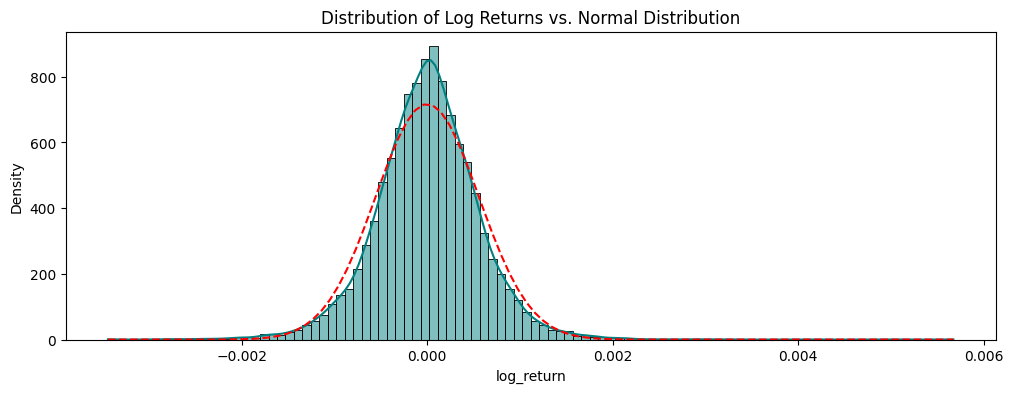

In [66]:
import seaborn as sns
from scipy.stats import norm

plt.figure(figsize=(12, 4))
sns.histplot(df_bars['log_return'], kde=True, stat="density", color='teal', bins=100)
# Overly a normal distribution for comparison
x = np.linspace(df_bars['log_return'].min(), df_bars['log_return'].max(), 100)
plt.plot(x, norm.pdf(x, df_bars['log_return'].mean(), df_bars['log_return'].std()), 'r--')
plt.title('Distribution of Log Returns vs. Normal Distribution')
plt.show()

### Autocorrelation Function (ACF) - Returns

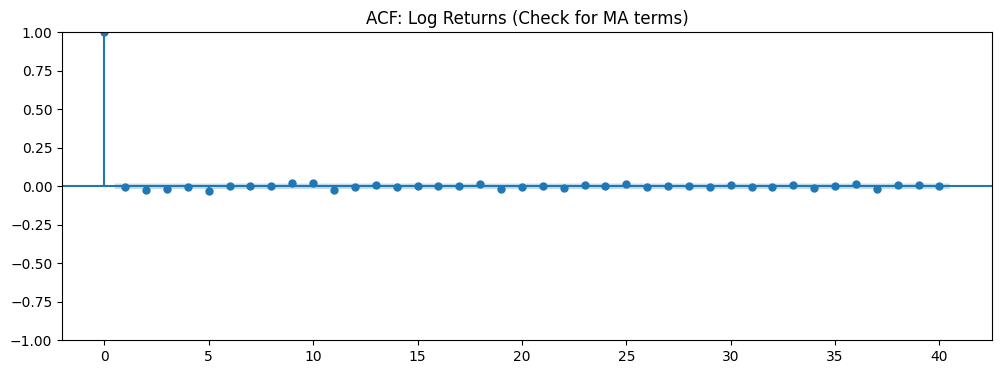

In [67]:
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df_bars['log_return'], lags=40, ax=ax)
plt.title('ACF: Log Returns (Check for MA terms)')
plt.show()

### Partial Autocorrelation Function (PACF) - Returns

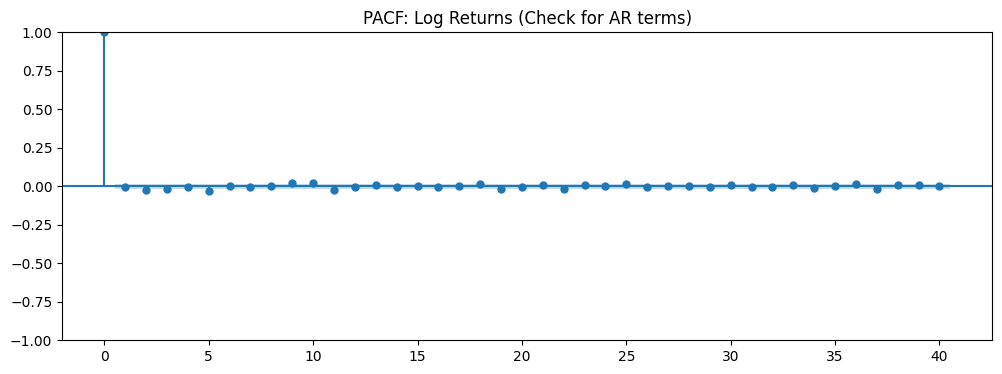

In [68]:
from statsmodels.graphics.tsaplots import plot_pacf
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(df_bars['log_return'], lags=40, ax=ax)
plt.title('PACF: Log Returns (Check for AR terms)')
plt.show()

### ACF of Squared Returns

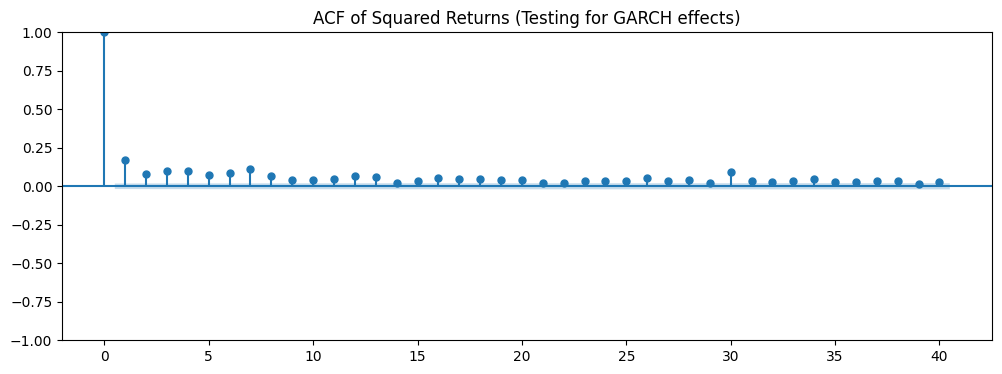

In [69]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df_bars['log_return']**2, lags=40, ax=ax)
plt.title('ACF of Squared Returns (Testing for GARCH effects)')
plt.show()

### Rolling Mean Spread

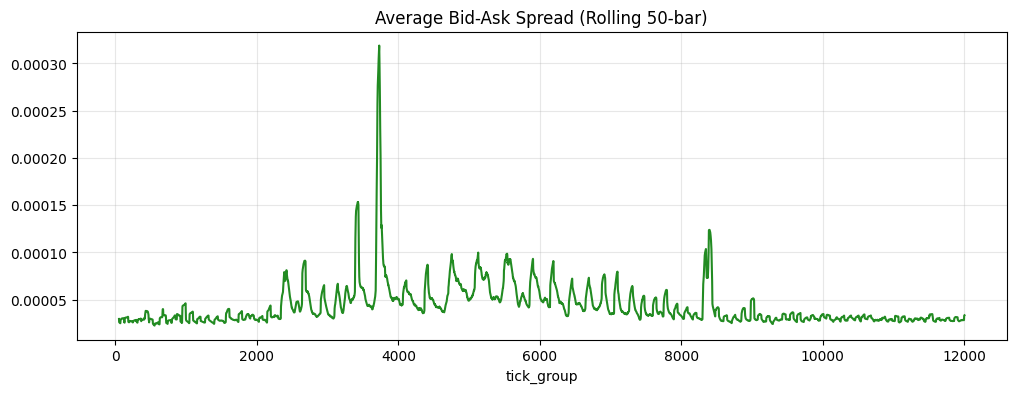

In [70]:
plt.figure(figsize=(12, 4))
df_bars['spread'].rolling(window=50).mean().plot(color='forestgreen')
plt.title('Average Bid-Ask Spread (Rolling 50-bar)')
plt.grid(True, alpha=0.3)
plt.show()

### Volume Analysis (Bid vs. Ask)

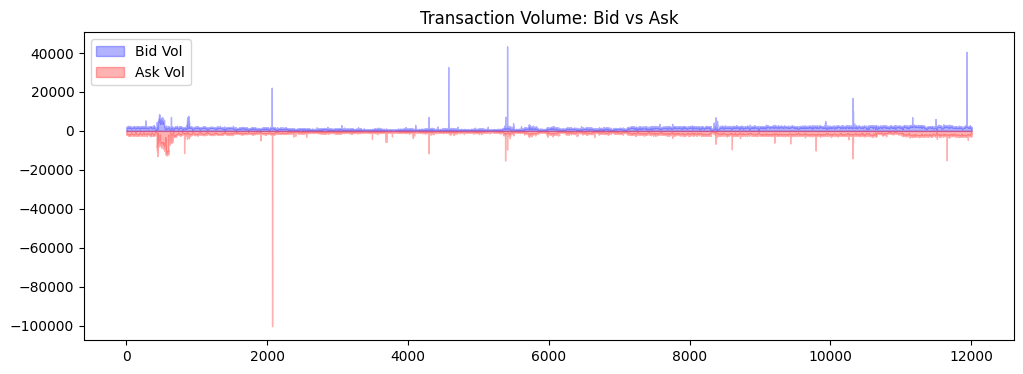

In [71]:
plt.figure(figsize=(12, 4))
plt.fill_between(df_bars.index, df_bars['bid_vol'], label='Bid Vol', color='blue', alpha=0.3)
plt.fill_between(df_bars.index, -df_bars['ask_vol'], label='Ask Vol', color='red', alpha=0.3)
plt.title('Transaction Volume: Bid vs Ask')
plt.legend()
plt.show()

### Quantile-Quantile (Q-Q) Plot

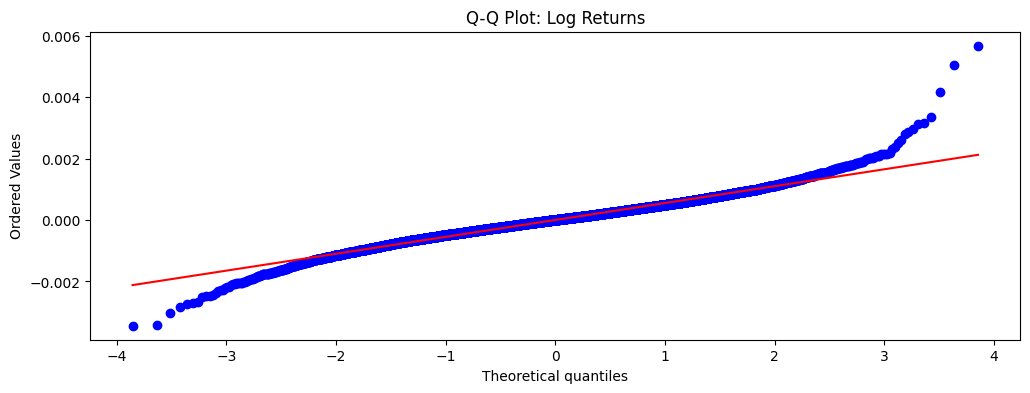

In [72]:
import scipy.stats as stats
plt.figure(figsize=(12, 4))
stats.probplot(df_bars['log_return'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Log Returns')
plt.show()

### Cumulative Log Returns

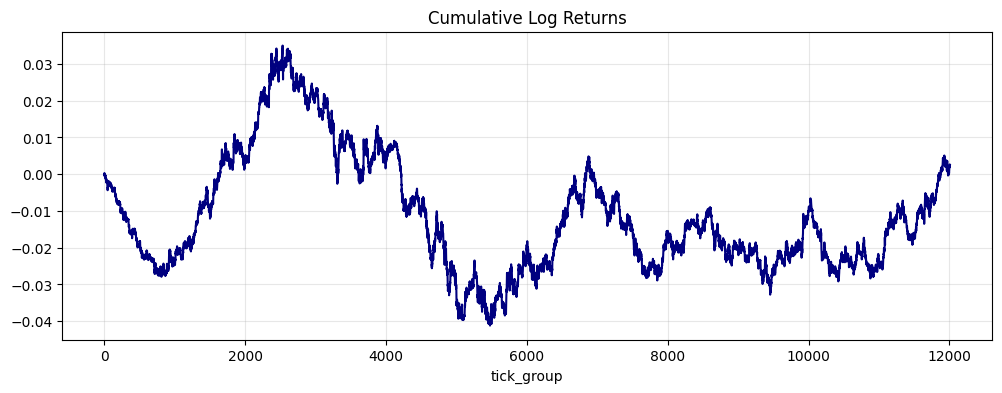

In [73]:
plt.figure(figsize=(12, 4))
df_bars['log_return'].cumsum().plot(color='navy')
plt.title('Cumulative Log Returns')
plt.grid(True, alpha=0.3)
plt.show()

### High-Frequency Volatility vs. Spread

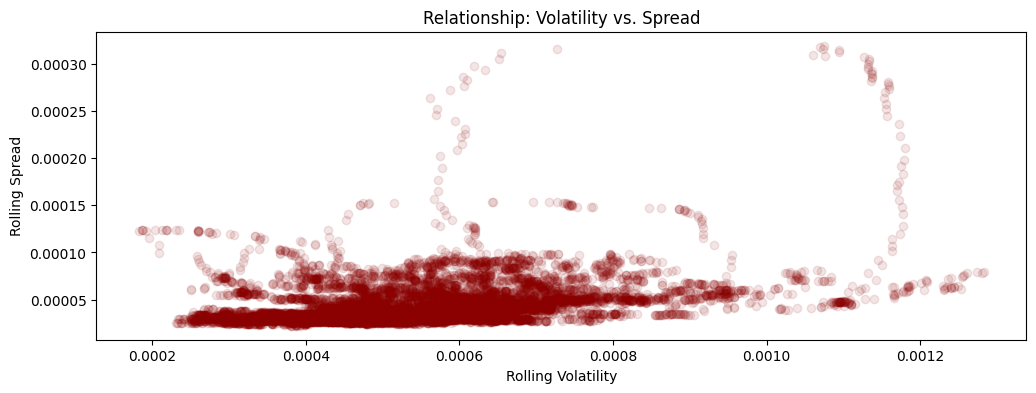

In [74]:
plt.figure(figsize=(12, 4))
vol = df_bars['log_return'].rolling(50).std()
spr = df_bars['spread'].rolling(50).mean()
plt.scatter(vol, spr, alpha=0.1, color='darkred')
plt.xlabel('Rolling Volatility')
plt.ylabel('Rolling Spread')
plt.title('Relationship: Volatility vs. Spread')
plt.show()

### Boxplot by Month

C:\Users\ofurn\AppData\Local\Temp\ipykernel_15112\140069443.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='log_return', data=df_bars, palette='viridis', fliersize=1)


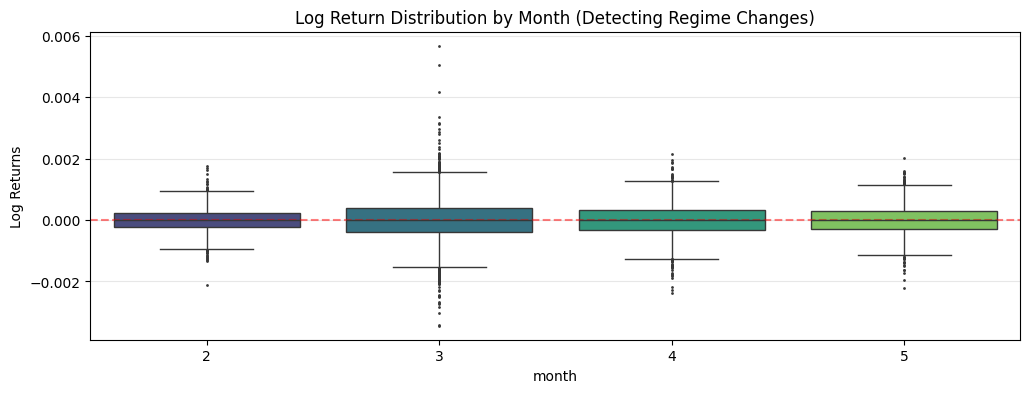

In [75]:
# Get the timestamps for all groups
all_group_timestamps = df.index.to_series().groupby(df['tick_group']).first()

# Filter timestamps to only include groups present in df_bars (the ones with valid returns)
df_bars.index = all_group_timestamps.loc[df_bars.index]

# Extract the month
df_bars['month'] = df_bars.index.month

plt.figure(figsize=(12, 4))
sns.boxplot(x='month', y='log_return', data=df_bars, palette='viridis', fliersize=1)
plt.title('Log Return Distribution by Month (Detecting Regime Changes)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.ylabel('Log Returns')
plt.grid(axis='y', alpha=0.3)
plt.show()

### The "Leverage Effect" Scatter

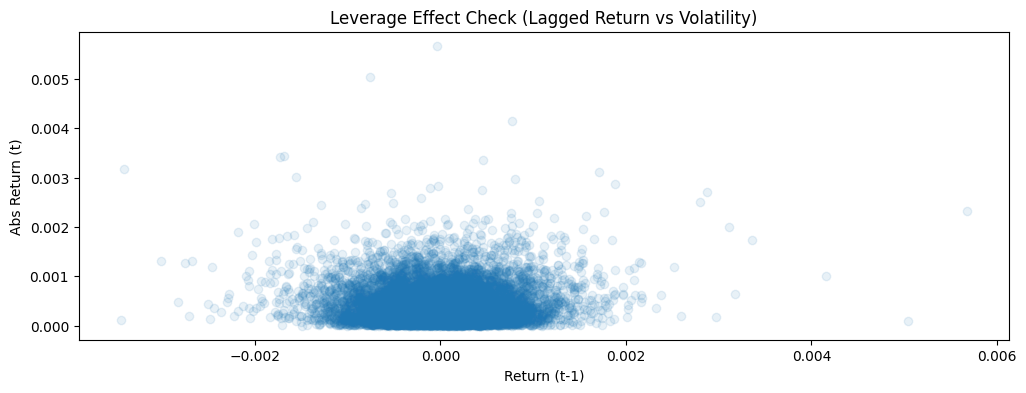

In [76]:
plt.figure(figsize=(12, 4))
plt.scatter(df_bars['log_return'].shift(1), df_bars['log_return'].abs(), alpha=0.1)
plt.xlabel('Return (t-1)')
plt.ylabel('Abs Return (t)')
plt.title('Leverage Effect Check (Lagged Return vs Volatility)')
plt.show()

### Rolling Skewness (Asymmetry in Returns)

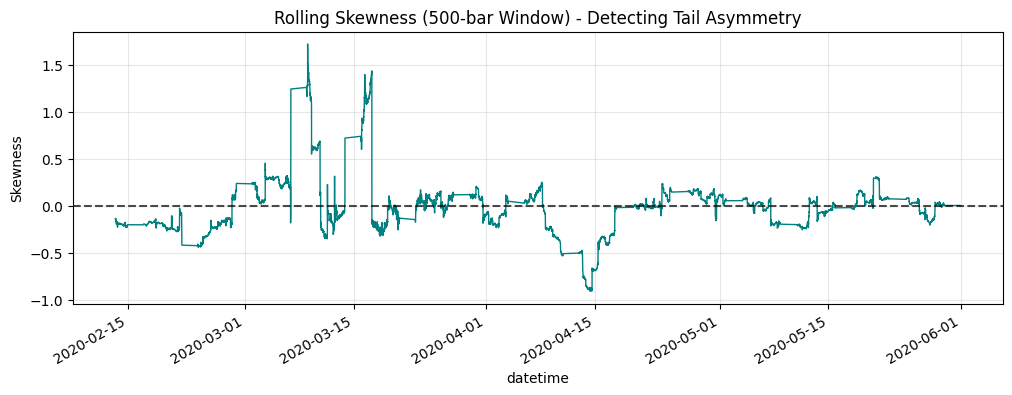

In [77]:
plt.figure(figsize=(12, 4))
df_bars['log_return'].rolling(window=500).skew().plot(color='teal', linewidth=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Rolling Skewness (500-bar Window) - Detecting Tail Asymmetry')
plt.ylabel('Skewness')
plt.grid(True, alpha=0.3)
plt.show()

### Intraday Seasonality: Spread by Hour

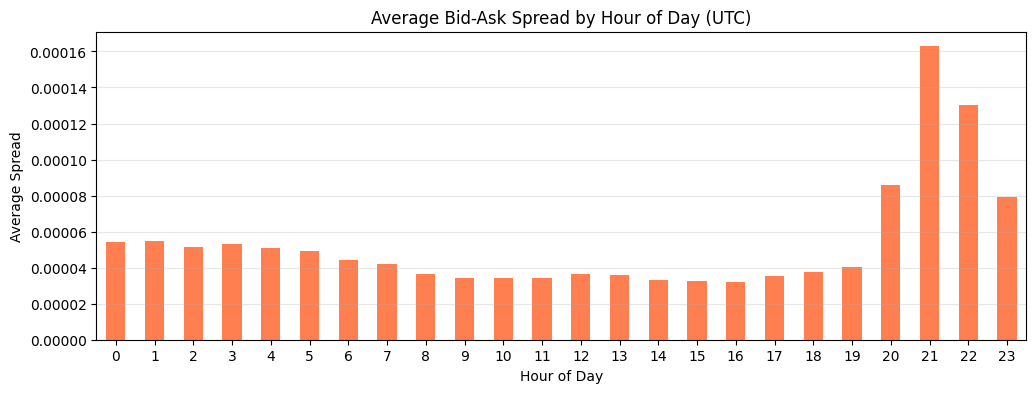

In [78]:
plt.figure(figsize=(12, 4))
# Group by the hour of the datetime index
df_bars.groupby(df_bars.index.hour)['spread'].mean().plot(kind='bar', color='coral')
plt.title('Average Bid-Ask Spread by Hour of Day (UTC)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Spread')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Intraday Seasonality: Volume by Hour

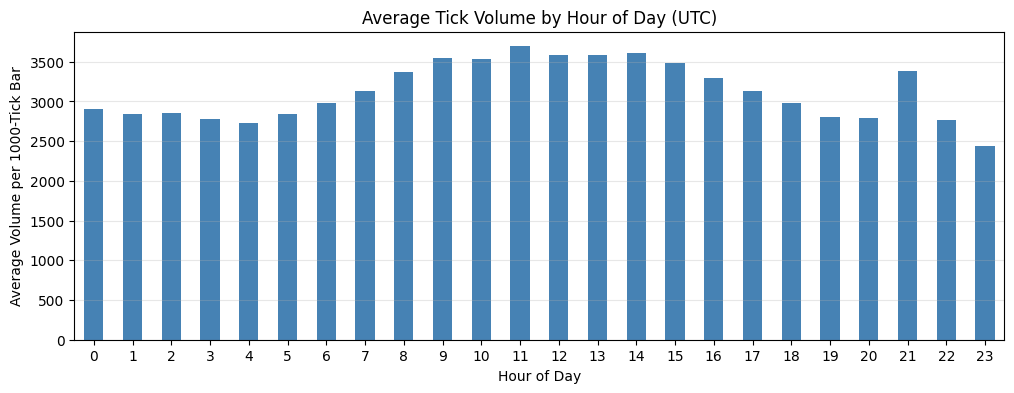

In [79]:
plt.figure(figsize=(12, 4))
total_vol = df_bars['bid_vol'] + df_bars['ask_vol']
total_vol.groupby(df_bars.index.hour).mean().plot(kind='bar', color='steelblue')
plt.title('Average Tick Volume by Hour of Day (UTC)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Volume per 1000-Tick Bar')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Order Flow Imbalance (OFI)

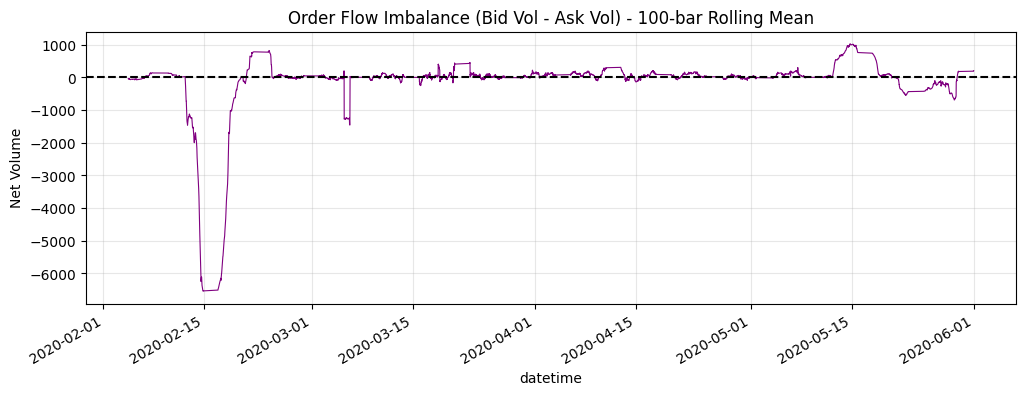

In [80]:
plt.figure(figsize=(12, 4))
# Create the OFI column
df_bars['OFI'] = df_bars['bid_vol'] - df_bars['ask_vol']
df_bars['OFI'].rolling(window=100).mean().plot(color='purple', linewidth=0.8)
plt.axhline(0, color='black', linestyle='--')
plt.title('Order Flow Imbalance (Bid Vol - Ask Vol) - 100-bar Rolling Mean')
plt.ylabel('Net Volume')
plt.grid(True, alpha=0.3)
plt.show()

### Information Arrival Rate (Time per Bar)

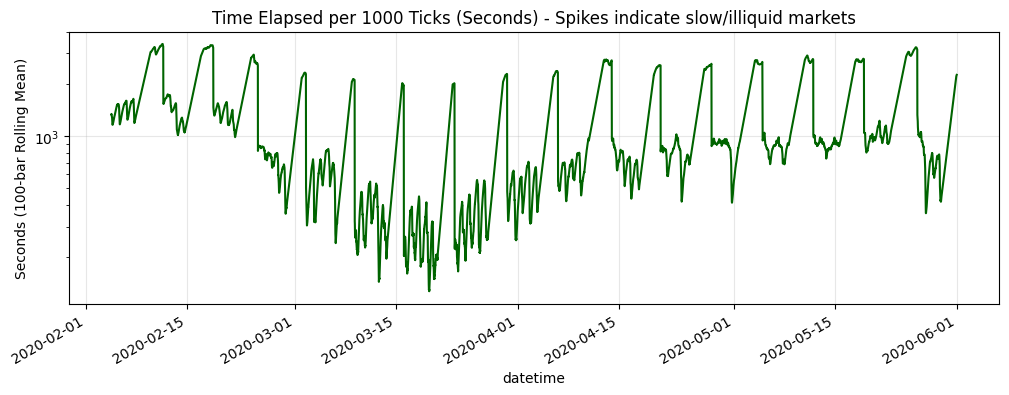

In [81]:
plt.figure(figsize=(12, 4))
# Calculate time difference in seconds between bars
time_diffs = df_bars.index.to_series().diff().dt.total_seconds()
time_diffs.rolling(100).mean().plot(color='darkgreen')
plt.title('Time Elapsed per 1000 Ticks (Seconds) - Spikes indicate slow/illiquid markets')
plt.ylabel('Seconds (100-bar Rolling Mean)')
plt.yscale('log') # Log scale helps handle the massive overnight quiet periods
plt.grid(True, alpha=0.3)
plt.show()

### EWMA vs. SMA Volatility (GARCH Precursor)

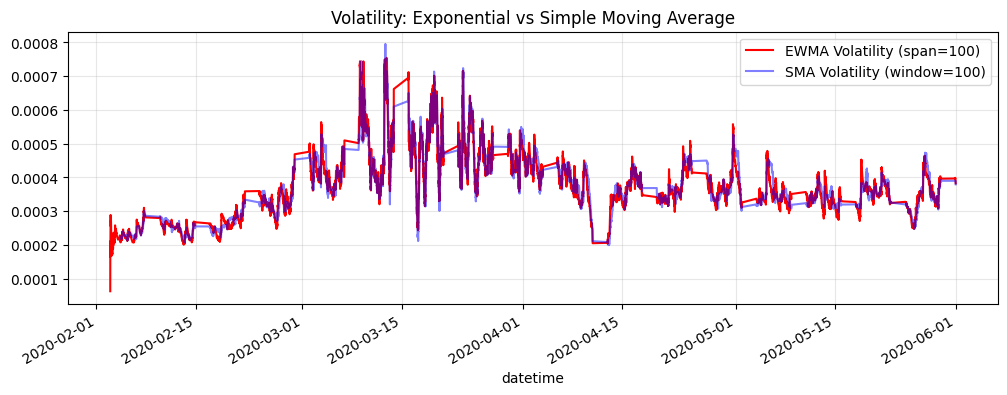

In [82]:
plt.figure(figsize=(12, 4))
df_bars['log_return'].abs().ewm(span=100).mean().plot(label='EWMA Volatility (span=100)', color='red')
df_bars['log_return'].abs().rolling(window=100).mean().plot(label='SMA Volatility (window=100)', color='blue', alpha=0.5)
plt.title('Volatility: Exponential vs Simple Moving Average')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Regime Proxy: High Vol vs. Low Vol Distributions

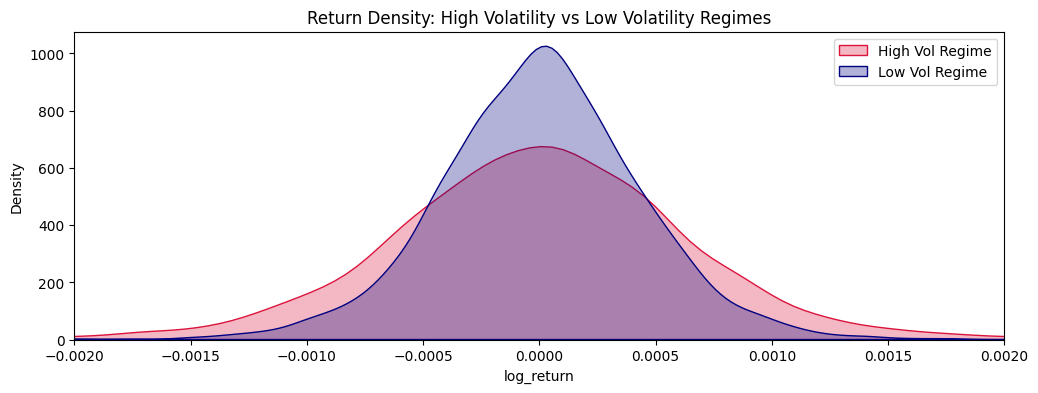

In [83]:
plt.figure(figsize=(12, 4))
# Define regimes based on trailing 50-bar volatility median
trailing_vol = df_bars['log_return'].rolling(50).std()
median_vol = trailing_vol.median()

sns.kdeplot(df_bars[trailing_vol > median_vol]['log_return'], label='High Vol Regime', color='crimson', fill=True, alpha=0.3)
sns.kdeplot(df_bars[trailing_vol <= median_vol]['log_return'], label='Low Vol Regime', color='navy', fill=True, alpha=0.3)
plt.xlim(-0.002, 0.002) # Zoom in to see the core distributions
plt.title('Return Density: High Volatility vs Low Volatility Regimes')
plt.legend()
plt.show()

### Phase Plot: Return(t) vs Return(t-1)

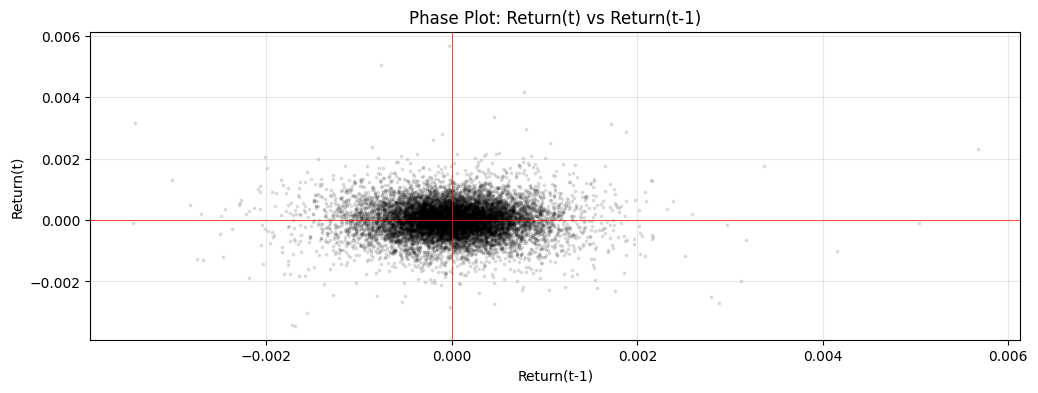

In [84]:
plt.figure(figsize=(12, 4))
plt.scatter(df_bars['log_return'].shift(1), df_bars['log_return'], alpha=0.1, s=3, color='k')
plt.title('Phase Plot: Return(t) vs Return(t-1)')
plt.xlabel('Return(t-1)')
plt.ylabel('Return(t)')
plt.axhline(0, color='red', lw=0.5)
plt.axvline(0, color='red', lw=0.5)
plt.grid(True, alpha=0.3)
plt.show()

### Cumulative OFI vs. Price Trajectory

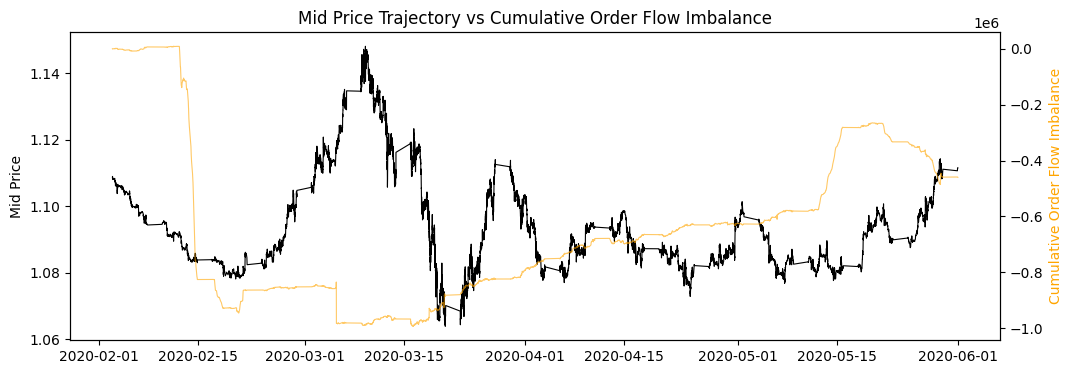

In [85]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(df_bars.index, df_bars['mid'], color='black', label='Mid Price', linewidth=0.8)
ax2.plot(df_bars.index, df_bars['OFI'].cumsum(), color='orange', label='Cumulative OFI', alpha=0.6, linewidth=0.8)

ax1.set_ylabel('Mid Price', color='black')
ax2.set_ylabel('Cumulative Order Flow Imbalance', color='orange')
plt.title('Mid Price Trajectory vs Cumulative Order Flow Imbalance')
plt.show()

### Amihud Illiquidity Proxy

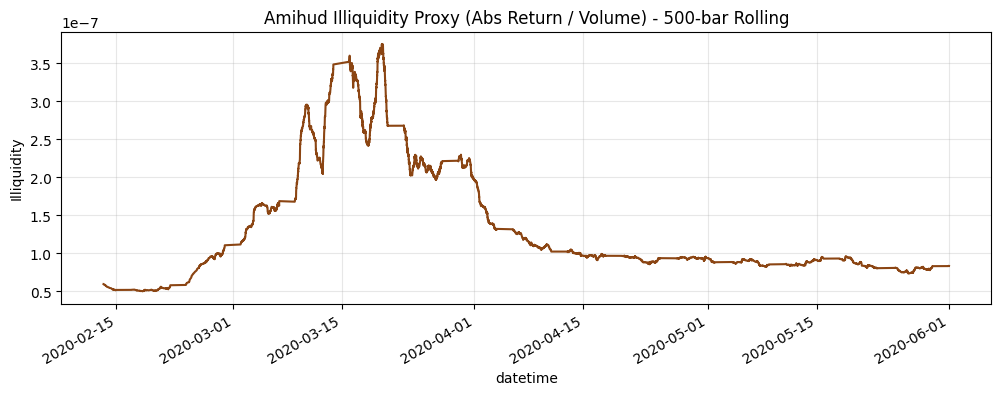

In [86]:
plt.figure(figsize=(12, 4))
total_vol = df_bars['bid_vol'] + df_bars['ask_vol']
illiquidity = df_bars['log_return'].abs() / total_vol
illiquidity.replace([np.inf, -np.inf], np.nan).rolling(500).mean().plot(color='saddlebrown')
plt.title('Amihud Illiquidity Proxy (Abs Return / Volume) - 500-bar Rolling')
plt.ylabel('Illiquidity')
plt.grid(True, alpha=0.3)
plt.show()

### Day of Week Effect

C:\Users\ofurn\AppData\Local\Temp\ipykernel_15112\2313103026.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_of_week', y='log_return', data=df_bars, order=order, fliersize=0.5, palette='Set2')


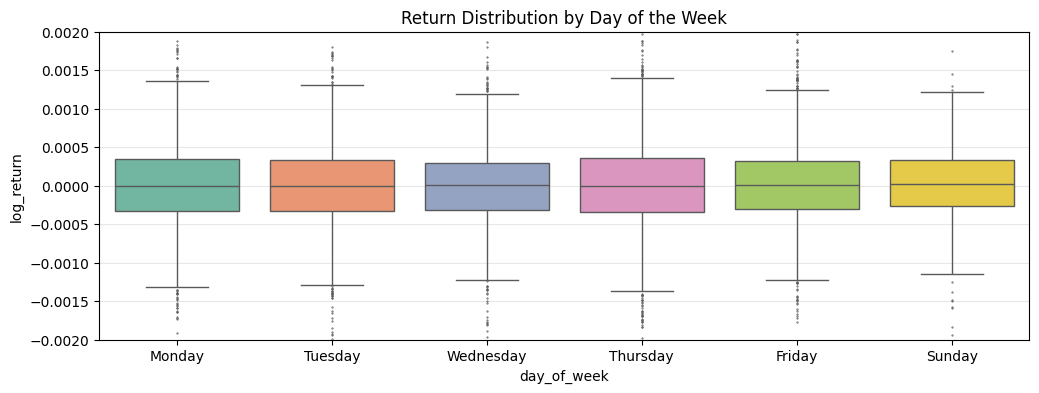

In [87]:
plt.figure(figsize=(12, 4))
df_bars['day_of_week'] = df_bars.index.day_name()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday'] # FX is closed Saturdays
sns.boxplot(x='day_of_week', y='log_return', data=df_bars, order=order, fliersize=0.5, palette='Set2')
plt.title('Return Distribution by Day of the Week')
plt.ylim(-0.002, 0.002) # Zoom to ignore extreme outliers
plt.grid(axis='y', alpha=0.3)
plt.show()

### Cross-Correlation: OFI vs Future Returns

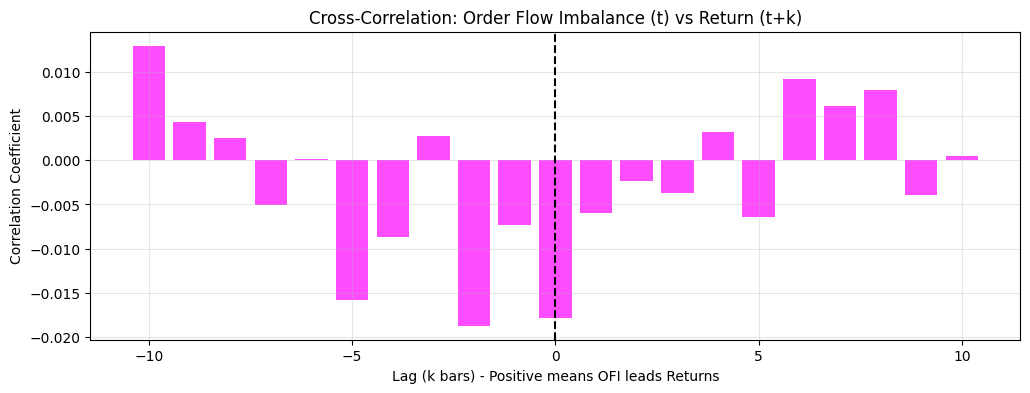

In [88]:
plt.figure(figsize=(12, 4))
lags = range(-10, 11)
# Calculate correlation between OFI and shifted returns
corrs = [df_bars['OFI'].corr(df_bars['log_return'].shift(-lag)) for lag in lags]
plt.bar(lags, corrs, color='magenta', alpha=0.7)
plt.title('Cross-Correlation: Order Flow Imbalance (t) vs Return (t+k)')
plt.xlabel('Lag (k bars) - Positive means OFI leads Returns')
plt.ylabel('Correlation Coefficient')
plt.axvline(0, color='black', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

### Rolling Autocorrelation (AR1 Stability)

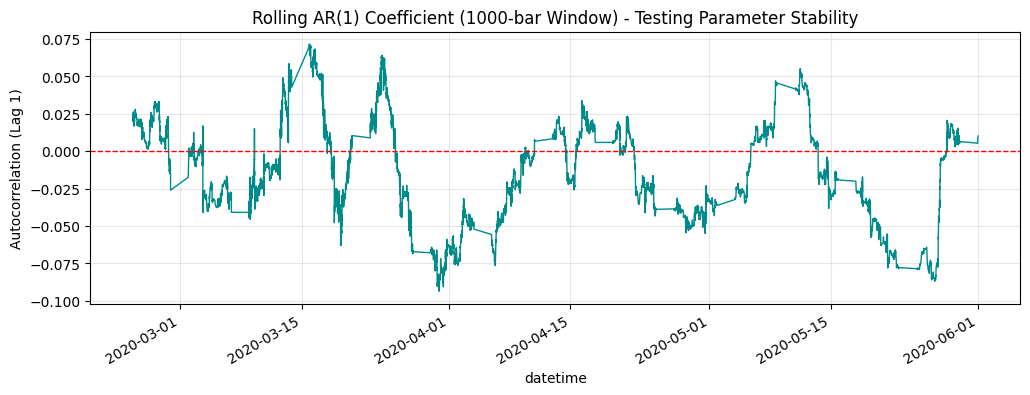

In [89]:
plt.figure(figsize=(12, 4))
# Calculate rolling 1-lag autocorrelation
rolling_ar1 = df_bars['log_return'].rolling(1000).apply(lambda x: x.autocorr(lag=1), raw=False)
rolling_ar1.plot(color='darkcyan', linewidth=1)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Rolling AR(1) Coefficient (1000-bar Window) - Testing Parameter Stability')
plt.ylabel('Autocorrelation (Lag 1)')
plt.grid(True, alpha=0.3)
plt.show()

### Bid-Ask Spread Density

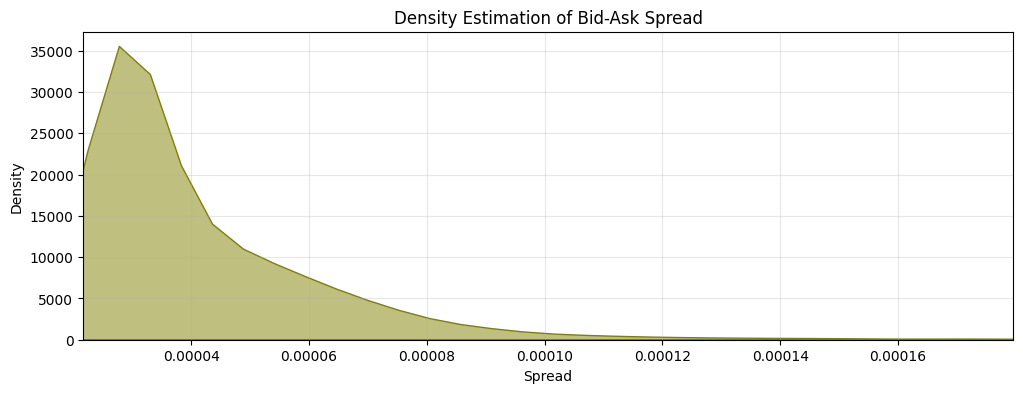

In [90]:
plt.figure(figsize=(12, 4))
sns.kdeplot(df_bars['spread'], fill=True, color='olive', alpha=0.5)
plt.title('Density Estimation of Bid-Ask Spread')
plt.xlabel('Spread')
# Limit x-axis to the 99th percentile to exclude massive, rare data gaps
plt.xlim(df_bars['spread'].quantile(0.01), df_bars['spread'].quantile(0.99)) 
plt.grid(True, alpha=0.3)
plt.show()

### Visualizing "Hidden Regimes" on the Price Chart

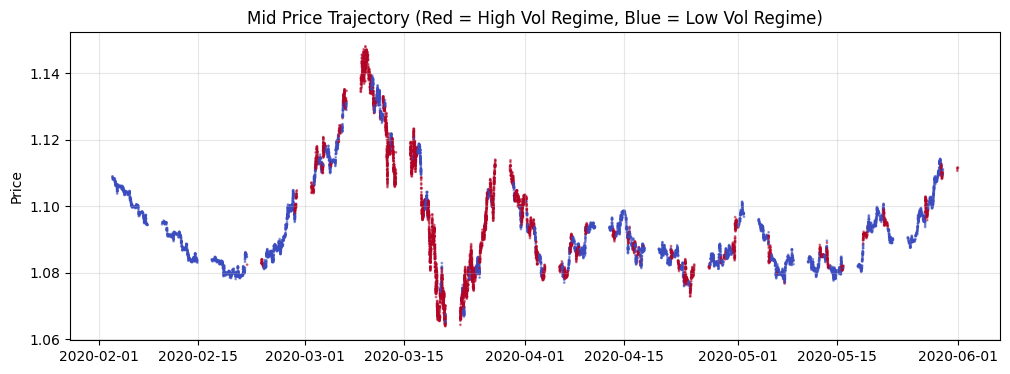

In [91]:
plt.figure(figsize=(12, 4))
trailing_vol = df_bars['log_return'].rolling(50).std()
high_vol = trailing_vol > trailing_vol.median()

# Scatter plot to allow coloring by regime
plt.scatter(df_bars.index, df_bars['mid'], c=high_vol, cmap='coolwarm', s=1, alpha=0.5)
plt.title('Mid Price Trajectory (Red = High Vol Regime, Blue = Low Vol Regime)')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.show()